# 09 - Trading signals: BUY / SELL decisions with explicit reasons

**What this does:** turns notebooks 01-08's data into concrete BUY and
SELL decisions - no price data needed - and explains EXACTLY why each
trade fired, with the numbers behind every conviction point. Two levels:
**themes -> anchor ETFs** (the primary strategy) and, at the bottom,
**individual tickers** (for backtest purposes).

**The philosophy: fewer trades, more conviction.** An entry needs
MOMENTUM and SENTIMENT to agree - neither alone is enough:

- **BUY** requires ALL of:
  1. momentum trigger: attention z (S1) or conviction z (S2) CROSSES
     above +K (crossing = yesterday <= K, today > K: one surge = one trade)
  2. sentiment agreement: the 5-day change of the net-bullish share is
     POSITIVE (mood improving vs its own baseline)
  3. conviction score >= MIN_SCORE (default 4 of 5)
- **SELL** is the mirror image: a bearish trigger (conviction z crosses
  below -K, or the crowded-top divergence activates: attention > K while
  mood deteriorates) + sentiment agreement (5d change NEGATIVE) + sell
  score >= MIN_SCORE_SELL. Expect sells to be rarer - retail skews
  bullish, so the bearish bar is genuinely harder to clear.

**Where the conviction score comes from (one point per check):**

| # | BUY check | SELL check |
|---|---|---|
| 1 | attention z > K (crowd unusually large) | same |
| 2 | 5d sentiment change > 0 (mood improving) | 5d change < 0 (deteriorating) |
| 3 | conviction z > K (crowd large AND bullish) | conviction z < -K |
| 4 | crowded-top flag NOT active | crowded-top flag ACTIVE |
| 5 | Reddit AND X mentions both rising (where X has coverage) | same |

Every trade's `reason` column spells the fired checks out with their
actual values, so nothing is a black box.

**FUTURE = LIVE:** all baselines are TRAILING (rolling 84d) - never
whole-window statistics - so this exact notebook becomes the daily signal
run when live ingestion lands. Signals on day t use only data <= t; the
order is stamped for the next day.

Needs: `daily_ticker_counts.parquet` (02) AND
`daily_theme_sentiment.parquet` (07); the ticker section also wants
`daily_ticker_sentiment.parquet` (06). Saves
`trade_signals.parquet` (themes) and `trade_signals_tickers.parquet`.

In [9]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [10]:
# ============ PARAMETERS - edit these ============
COUNTS_PATH    = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts.parquet')
THEME_SENT     = os.path.join(ROOT, 'data', 'processed', 'daily_theme_sentiment.parquet')
TICKER_SENT    = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_sentiment.parquet')
BY_SOURCE      = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts_by_source.parquet')
SIGNALS_OUT    = os.path.join(ROOT, 'data', 'processed', 'trade_signals.parquet')
TICKER_OUT     = os.path.join(ROOT, 'data', 'processed', 'trade_signals_tickers.parquet')
START_DATE     = None    # 'YYYY-MM-DD' or None = whole file
END_DATE       = None    # exclusive
K              = 2.0     # z threshold for the momentum triggers
MIN_SCORE      = 4       # BUY needs at least this many of the 5 checks
MIN_SCORE_SELL = 3       # bearish checks are harder to clear (bullish-bias floor)
ROLL           = 7       # rolling sum window (days)
BASELINE       = 84      # trailing baseline for the z (days)
MIN_DAYS       = 28      # history needed before a z exists (warm-up)
MIN_DAILY_MENTIONS = 5   # theme volume floor
MIN_TICKER_MENTIONS = 10 # ticker volume floor (single names are noisier)
MAX_TICKER_CHARTS   = 8  # cap on individual-ticker charts
# ==================================================

In [11]:
# Build the per-theme series with TRAILING z-scores (live-parity rule).
import numpy as np
import pandas as pd
import importlib
import src.themes
importlib.reload(src.themes)
from src.themes import THEME_ETFS, build_ticker_to_themes

if not os.path.exists(COUNTS_PATH):
    raise FileNotFoundError('daily_ticker_counts.parquet not found - run notebooks 01+02 first.')
if not os.path.exists(THEME_SENT):
    raise FileNotFoundError(
        'daily_theme_sentiment.parquet not found - run notebook 07 first. '
        'BUY/SELL here is BY DESIGN a combination of momentum AND sentiment.')

counts = pd.read_parquet(COUNTS_PATH)
counts['date'] = pd.to_datetime(counts['date'])
if START_DATE: counts = counts[counts['date'] >= START_DATE]
if END_DATE:   counts = counts[counts['date'] < END_DATE]
WINDOW = f"{counts['date'].min().date()} to {counts['date'].max().date()}"
print('window:', WINDOW)

lookup = build_ticker_to_themes()
counts['themes'] = counts['ticker'].map(lambda t: lookup.get(t, []))
theme_rows = counts.explode('themes').dropna(subset=['themes'])
theme_daily = (theme_rows.groupby(['date', 'themes'])['mention_count'].sum()
               .rename('mentions').reset_index().rename(columns={'themes': 'theme'}))

all_days = pd.date_range(counts['date'].min(), counts['date'].max(), freq='D')
wide = (theme_daily.pivot_table(index='date', columns='theme', values='mentions')
        .reindex(all_days).fillna(0))
wide = wide.loc[:, wide.mean() >= MIN_DAILY_MENTIONS]
print('themes with enough volume:', list(wide.columns))

def trailing_z(frame):
    """7d rolling sum, z-scored against a TRAILING 84d baseline only."""
    r = frame.rolling(ROLL, min_periods=1).sum()
    mu = r.rolling(BASELINE, min_periods=MIN_DAYS).mean()
    sd = r.rolling(BASELINE, min_periods=MIN_DAYS).std().replace(0, np.nan)
    return (r - mu) / sd

att_z = trailing_z(wide)   # momentum ingredient 1: attention

window: 2021-01-01 to 2021-12-31
themes with enough volume: ['ai', 'ai_megacap', 'biotech_pharma', 'china_geopolitics', 'cloud_saas', 'consumer_retail', 'crypto', 'ev_clean_energy', 'meme_stocks', 'semiconductors', 'short_squeeze']


In [12]:
# Sentiment ingredients (REQUIRED) + optional cross-source check.
ts = pd.read_parquet(THEME_SENT)
ts['date'] = pd.to_datetime(ts['date'])
wn = (ts.pivot_table(index='date', columns='theme', values='n_posts')
      .reindex(all_days).fillna(0))
wb = (ts.pivot_table(index='date', columns='theme', values='net_bullish')
      .reindex(all_days))
pressure = (wn * wb).fillna(0)
conv_z = trailing_z(pressure)
share = (pressure.rolling(ROLL, min_periods=1).sum()
         / wn.rolling(ROLL, min_periods=1).sum().replace(0, np.nan))
sent_change = share.diff(5)
crowded = (att_z.reindex(columns=share.columns) > 1) & (sent_change < -0.10)
print('theme sentiment loaded for', wb.shape[1], 'themes')

both_rising = None
if os.path.exists(BY_SOURCE):
    bs = pd.read_parquet(BY_SOURCE)
    bs['date'] = pd.to_datetime(bs['date'])
    bs['themes'] = bs['ticker'].map(lambda t: lookup.get(t, []))
    bst = (bs.explode('themes').dropna(subset=['themes'])
           .groupby(['date', 'source', 'themes'])['mention_count'].sum().reset_index())
    if set(bst['source'].unique()) >= {'reddit', 'x'}:
        def src_roll(name):
            w = (bst[bst['source'] == name]
                 .pivot_table(index='date', columns='themes', values='mention_count')
                 .reindex(all_days).fillna(0))
            return w.rolling(ROLL, min_periods=1).sum()
        r7, x7 = src_roll('reddit'), src_roll('x')
        x_active = x7.rolling(30, min_periods=1).max() > 0
        both_rising = (r7.diff(5) > 0) & (x7.diff(5) > 0) & x_active
        print('cross-source check active where X has coverage')

theme sentiment loaded for 21 themes
cross-source check active where X has coverage


In [13]:
# THE DECISION ENGINE - shared by themes and (below) individual tickers.
def crosses_above(z, k): return (z > k) & (z.shift(1) <= k)
def crosses_below(z, k): return (z < k) & (z.shift(1) >= k)

def _val(frame, day, name):
    if frame is None or name not in frame.columns:
        return None
    v = frame.at[day, name]
    return None if pd.isna(v) else float(v)

def make_decisions(names, az_f, cz_f, dv_f, crowd_f, xrise_f, instrument_of):
    """Apply the momentum+sentiment+score rules to every name.
    Returns the trade log with per-trade reasons."""
    out = []
    for name in names:
        if name not in cz_f.columns:
            continue
        buy_t = crosses_above(az_f[name], K) | crosses_above(cz_f[name], K)
        newly_crowded = (crowd_f[name] & ~crowd_f[name].shift(1).fillna(False)
                         if name in crowd_f.columns else pd.Series(False, index=all_days))
        sell_t = crosses_below(cz_f[name], -K) | newly_crowded

        for day in all_days[(buy_t | sell_t).fillna(False)]:
            az, cz, dv = _val(az_f, day, name), _val(cz_f, day, name), _val(dv_f, day, name)
            is_crowded = bool(crowd_f.at[day, name]) if name in crowd_f.columns else False
            xr = (bool(xrise_f.at[day, name])
                  if xrise_f is not None and name in xrise_f.columns else None)

            if bool(buy_t.get(day, False)) and dv is not None and dv > 0:
                side, min_needed = 'BUY', MIN_SCORE
                checks = [
                    (az is not None and az > K,  f'attention surged (z {az:+.2f} > {K})' if az is not None else ''),
                    (True,                       f'mood improving (5d sentiment {dv:+.3f} > 0)'),
                    (cz is not None and cz > K,  f'crowd leaning bullish (conviction z {cz:+.2f} > {K})' if cz is not None else ''),
                    (not is_crowded,             'no crowded-top warning'),
                    (xr is True,                 'Reddit AND X both rising'),
                ]
            elif bool(sell_t.get(day, False)) and dv is not None and dv < 0:
                side, min_needed = 'SELL', MIN_SCORE_SELL
                checks = [
                    (az is not None and az > K,   f'attention surged (z {az:+.2f} > {K})' if az is not None else ''),
                    (True,                        f'mood deteriorating (5d sentiment {dv:+.3f} < 0)'),
                    (cz is not None and cz < -K,  f'crowd leaning bearish (conviction z {cz:+.2f} < -{K})' if cz is not None else ''),
                    (is_crowded,                  'crowded-top divergence ACTIVE (crowd up, mood down)'),
                    (xr is True,                  'Reddit AND X both rising'),
                ]
            else:
                continue   # momentum fired but sentiment disagreed -> NO trade

            score = sum(1 for ok, _ in checks if ok)
            if score < min_needed:
                continue   # fewer trades, more conviction
            reason = ' + '.join(txt for ok, txt in checks if ok and txt)
            instr = instrument_of(name)
            out.append({'signal_date': day.date(),
                        'action_date': (day + pd.Timedelta(days=1)).date(),
                        'action': side, 'name': name, 'instrument': instr,
                        'score': score, 'att_z': az, 'conv_z': cz, 'sent_5d_chg': dv,
                        'reason': f'{side} {instr}: {reason} -> score {score}/5'})
    return pd.DataFrame(out).sort_values('signal_date').reset_index(drop=True) if out else pd.DataFrame()

trades = make_decisions(wide.columns, att_z, conv_z, sent_change, crowded,
                        both_rising, lambda th: THEME_ETFS.get(th, '?'))
if len(trades):
    trades = trades.rename(columns={'name': 'theme', 'instrument': 'etf'})
    trades.to_parquet(SIGNALS_OUT, index=False)
print(f'{len(trades)} THEME decisions in {WINDOW} '
      f'(BUY: {(trades["action"] == "BUY").sum() if len(trades) else 0}, '
      f'SELL: {(trades["action"] == "SELL").sum() if len(trades) else 0}) -> {SIGNALS_OUT}')
if len(trades):
    print('\n--- every decision, spelled out ---')
    for _, t in trades.iterrows():
        print(f"{t['signal_date']}  {t['reason']}")
trades.drop(columns=['reason']) if len(trades) else trades

46 THEME decisions in 2021-01-01 to 2021-12-31 (BUY: 21, SELL: 25) -> c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\trade_signals.parquet

--- every decision, spelled out ---
2021-01-28  SELL XBI: attention surged (z +2.85 > 2.0) + mood deteriorating (5d sentiment -0.114 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
2021-01-28  SELL IGV: attention surged (z +2.81 > 2.0) + mood deteriorating (5d sentiment -0.202 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
2021-01-28  SELL XLY: mood deteriorating (5d sentiment -0.375 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 3/5
2021-01-31  BUY SMH: attention surged (z +2.19 > 2.0) + mood improving (5d sentiment +0.152 > 0) + crowd leaning bullish (conviction z +2.29 > 2.0) + no crowded-top warning -> score 4/5
2021-02-03  BUY IGV: mood improving (5d sentiment +0.075 > 0) + crowd leaning 

C:\Users\alexd\AppData\Local\Temp\ipykernel_21308\3994885965.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  newly_crowded = (crowd_f[name] & ~crowd_f[name].shift(1).fillna(False)


,signal_date,action_date,action,theme,etf,score,att_z,conv_z,sent_5d_chg
0,2021-01-28,2021-01-29,SELL,biotech_pharma,XBI,4,2.847101,3.064432,-0.113884
1,2021-01-28,2021-01-29,SELL,cloud_saas,IGV,4,2.811175,1.494678,-0.202173
2,2021-01-28,2021-01-29,SELL,consumer_retail,XLY,3,1.330620,1.514840,-0.375146
3,2021-01-31,2021-02-01,BUY,semiconductors,SMH,4,2.191289,2.287657,0.152101
4,2021-02-03,2021-02-04,BUY,cloud_saas,IGV,4,-0.155170,2.708679,0.074675
5,2021-02-19,2021-02-20,BUY,cloud_saas,IGV,4,1.051428,2.684344,0.124713
6,2021-05-17,2021-05-18,SELL,biotech_pharma,XBI,3,-1.170212,-2.048049,-0.251337
7,2021-06-02,2021-06-03,BUY,meme_stocks,GME,4,2.212650,0.610608,0.091876
8,2021-06-02,2021-06-03,BUY,short_squeeze,GME,5,2.245526,2.821349,0.102348
9,2021-06-06,2021-06-07,BUY,meme_stocks,GME,5,3.702770,2.021899,0.014701


## Theme charts - every decision annotated

Attention z (blue) and conviction z (orange) with +K/-K dashed. **Green
up-triangle = BUY, red down-triangle = SELL** (order executes next day);
the number is the conviction score. Grey band = warm-up. Surges WITHOUT
a triangle are the gate rejecting low-conviction setups - the
fewer-trades-more-conviction rule made visible.

themes with decisions: ['biotech_pharma', 'cloud_saas', 'consumer_retail', 'semiconductors', 'meme_stocks', 'short_squeeze', 'ev_clean_energy', 'ai_megacap', 'ai']


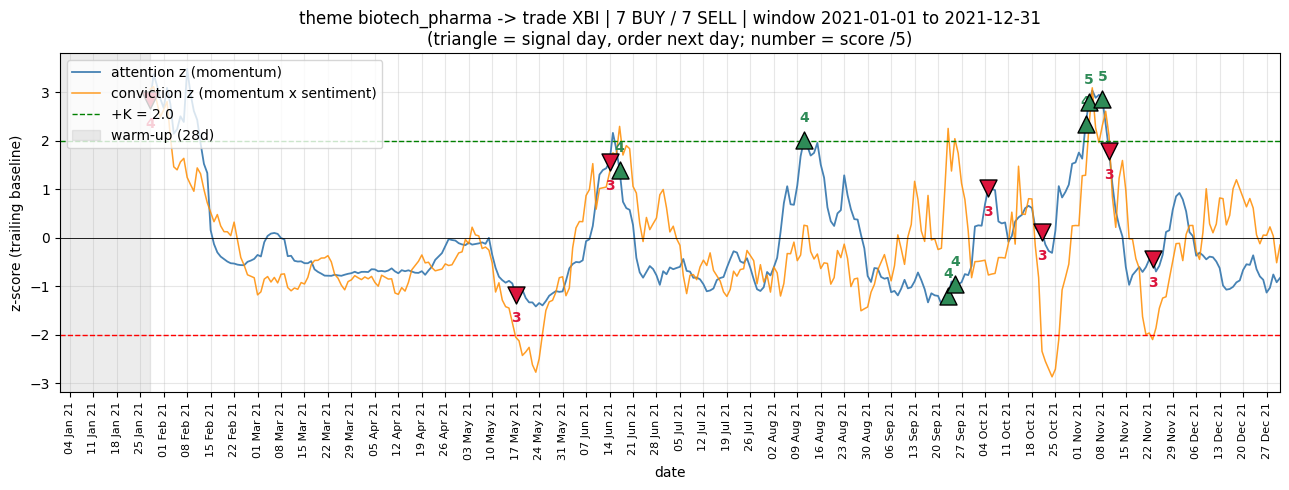

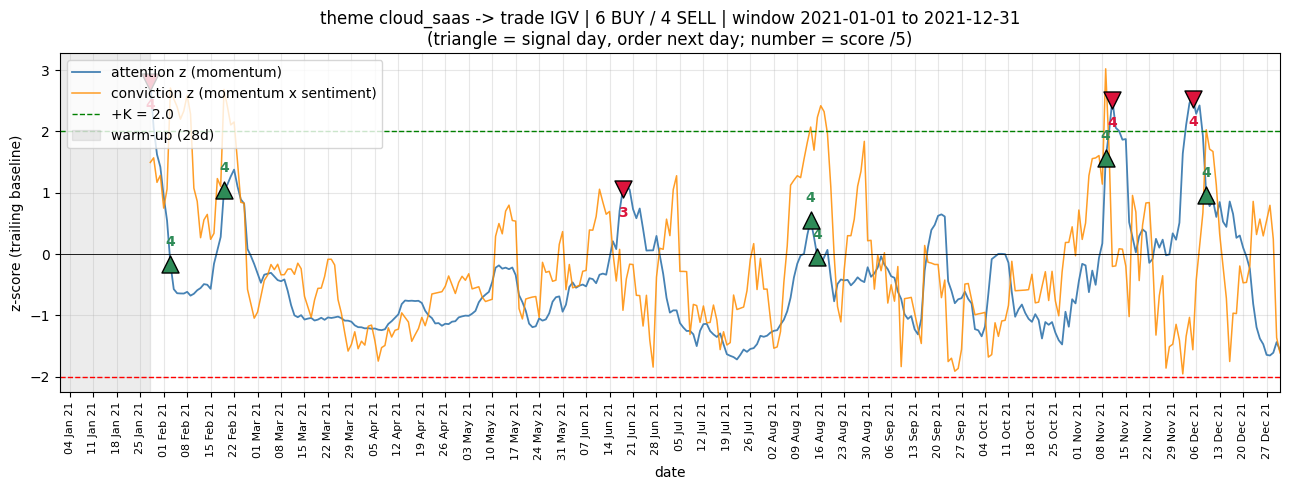

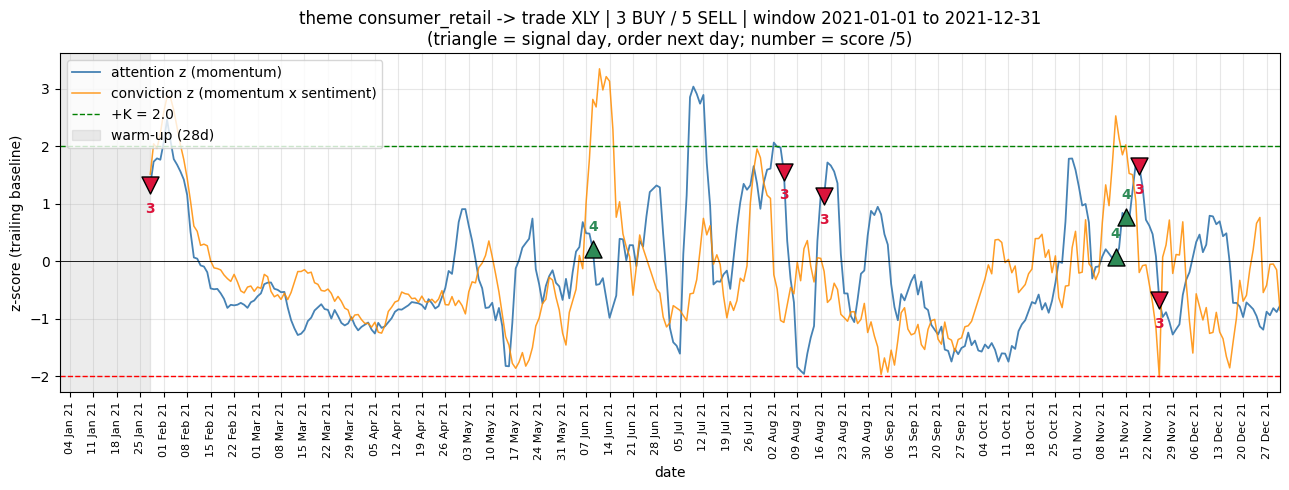

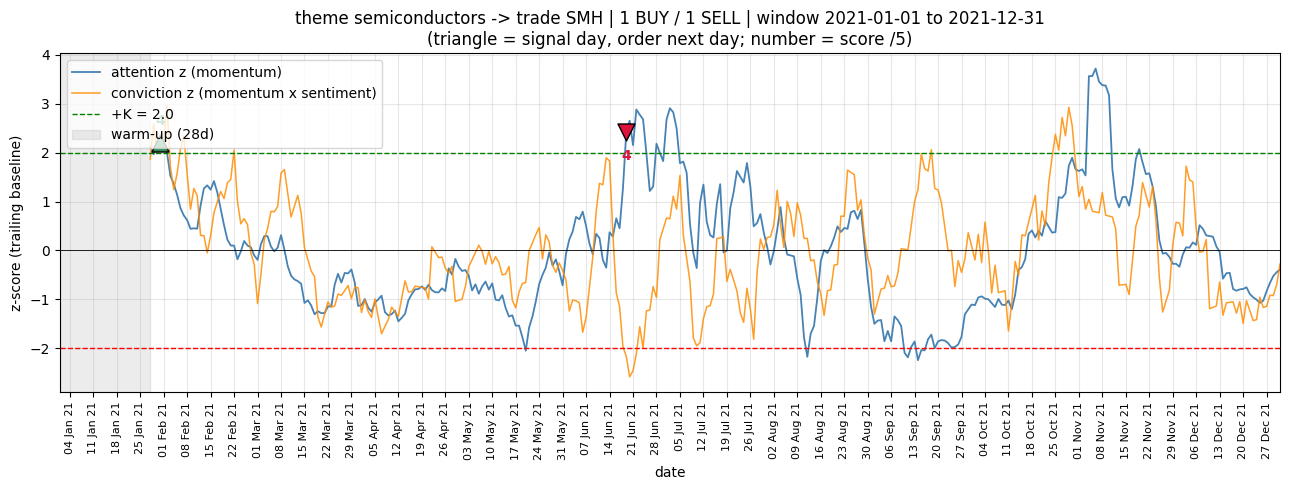

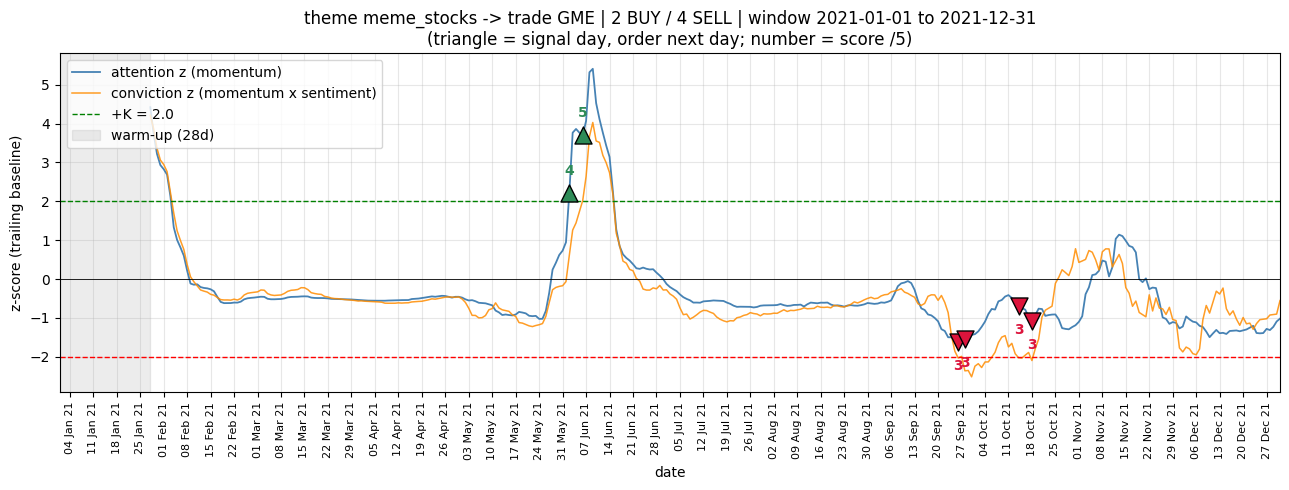

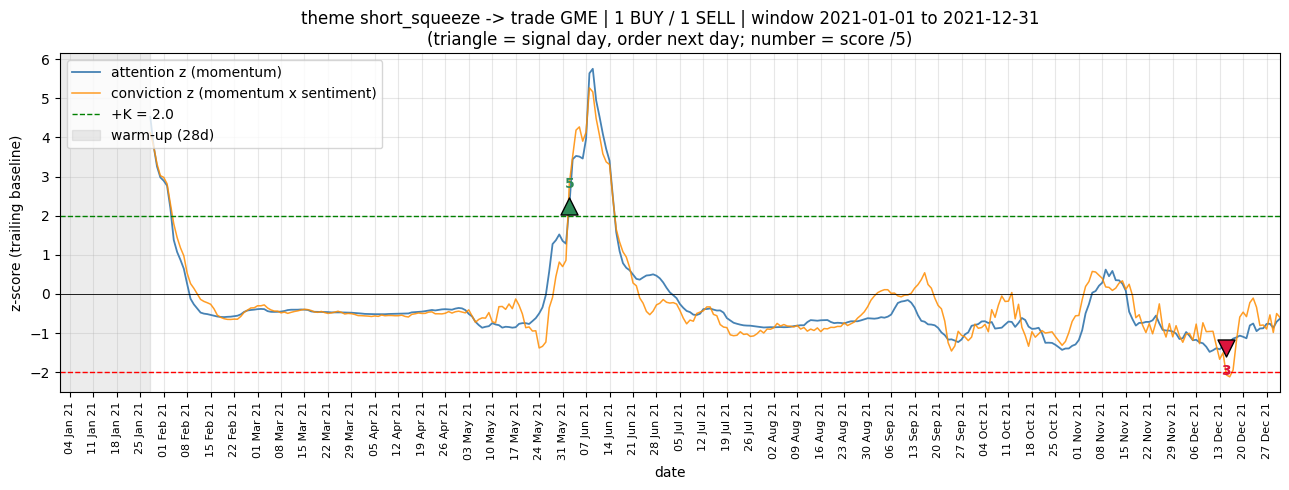

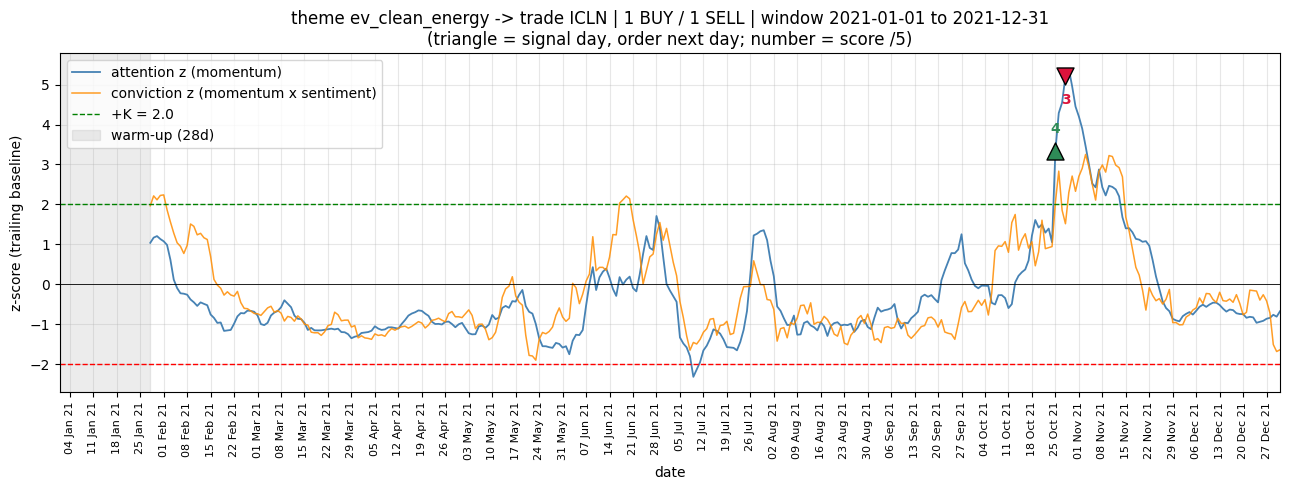

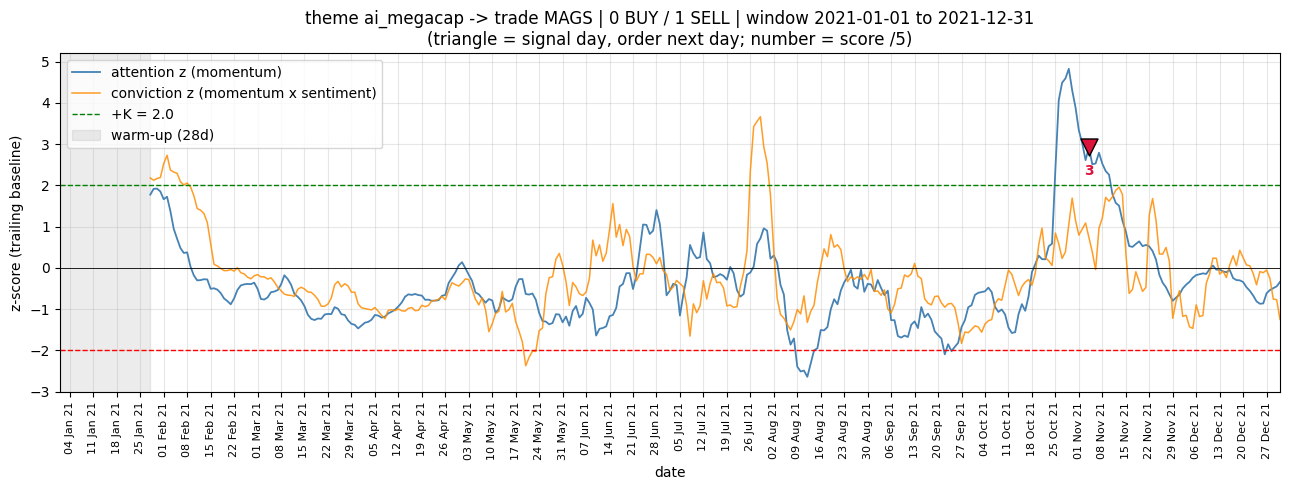

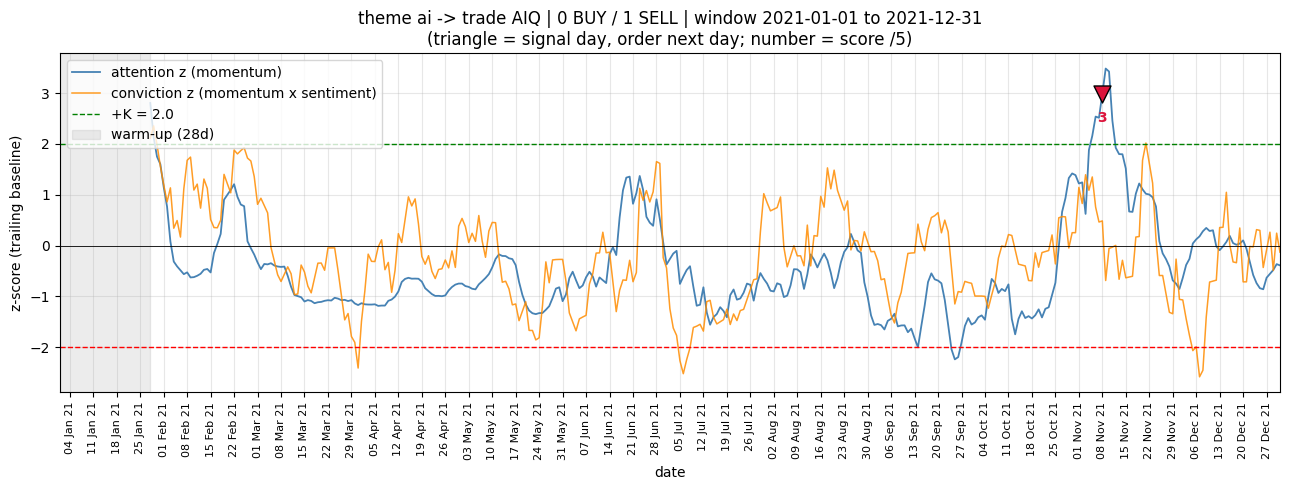

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def format_date_axis(ax, index):
    """Weekly ticks (every Monday), auto-thinned to ~55 labels max if the
    window grows beyond a year, so this stays readable when live data lands."""
    n_weeks = max(1, (index[-1] - index[0]).days / 7)
    interval = max(1, int(np.ceil(n_weeks / 55)))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_xlim(index[0], index[-1])

def plot_decisions(name, az_f, cz_f, tt, instrument, label):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(az_f.index, az_f[name], linewidth=1.3, color='steelblue',
            label='attention z (momentum)')
    if name in cz_f.columns:
        ax.plot(cz_f.index, cz_f[name], linewidth=1.1, color='darkorange',
                alpha=0.85, label='conviction z (momentum x sentiment)')
    ax.axhline(K, color='green', linestyle='--', linewidth=1, label=f'+K = {K}')
    ax.axhline(-K, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.6)
    valid_from = az_f[name].first_valid_index()
    if valid_from is not None and valid_from > az_f.index[0]:
        ax.axvspan(az_f.index[0], valid_from, color='gray', alpha=0.15,
                   label=f'warm-up ({MIN_DAYS}d)')
    for _, tr in tt.iterrows():
        day = pd.Timestamp(tr['signal_date'])
        y = tr['att_z'] if tr['att_z'] is not None else tr['conv_z']
        up = tr['action'] == 'BUY'
        ax.scatter([day], [y], marker='^' if up else 'v', s=150,
                   color='seagreen' if up else 'crimson', edgecolors='black', zorder=5)
        ax.annotate(str(tr['score']), (day, y), textcoords='offset points',
                    xytext=(0, 13 if up else -20), ha='center', fontsize=10,
                    fontweight='bold', color='seagreen' if up else 'crimson')
    n_buy = (tt['action'] == 'BUY').sum(); n_sell = (tt['action'] == 'SELL').sum()
    ax.set_title(f'{label} {name} -> trade {instrument} | {n_buy} BUY / {n_sell} SELL | '
                 f'window {WINDOW}\n(triangle = signal day, order next day; number = score /5)')
    ax.set_ylabel('z-score (trailing baseline)'); ax.set_xlabel('date')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
    format_date_axis(ax, az_f.index)
    plt.tight_layout(); plt.show()

fired = trades['theme'].unique().tolist() if len(trades) else []
print('themes with decisions:', fired if fired else
      'none - try lowering MIN_SCORE or K, or widen the window in notebook 01')
for theme in fired:
    plot_decisions(theme, att_z, conv_z, trades[trades['theme'] == theme],
                   THEME_ETFS.get(theme, '?'), 'theme')

## Individual tickers (for backtest purposes)

The SAME decision engine, run per single ticker: attention from its own
mention counts, sentiment from notebook 06's per-ticker file, identical
gates and scoring. The instrument bought/sold is the ticker itself.

Read the results with two extra warnings that don't apply to themes:

- **Noisier by construction** - a single name's sentiment rests on far
  fewer posts, hence the higher volume floor (`MIN_TICKER_MENTIONS`).
- **Survivorship in the backtest** - the DELISTED supplement restores
  their MENTIONS, but notebook 10 will need delisted names' PRICE data
  (Bloomberg) or single-name results will be flattered by skipping
  exactly the trades that went to zero.

In [15]:
# Build per-TICKER ingredients and run the same engine.
t_wide = (counts.pivot_table(index='date', columns='ticker', values='mention_count',
                             aggfunc='sum')
          .reindex(all_days).fillna(0))
t_wide = t_wide.loc[:, t_wide.mean() >= MIN_TICKER_MENTIONS]
print(len(t_wide.columns), 'tickers above the volume floor')
t_att_z = trailing_z(t_wide)

ticker_trades = pd.DataFrame()
if not os.path.exists(TICKER_SENT):
    print('daily_ticker_sentiment.parquet missing - run notebook 06 to enable')
    print('ticker-level decisions (sentiment is required, same as for themes).')
else:
    tks = pd.read_parquet(TICKER_SENT)
    tks['date'] = pd.to_datetime(tks['date'])
    t_wn = (tks.pivot_table(index='date', columns='ticker', values='n_posts')
            .reindex(all_days).fillna(0))
    t_wb = (tks.pivot_table(index='date', columns='ticker', values='net_bullish')
            .reindex(all_days))
    t_pressure = (t_wn * t_wb).fillna(0)
    t_conv_z = trailing_z(t_pressure)
    t_share = (t_pressure.rolling(ROLL, min_periods=1).sum()
               / t_wn.rolling(ROLL, min_periods=1).sum().replace(0, np.nan))
    t_sent_change = t_share.diff(5)
    t_crowded = ((t_att_z.reindex(columns=t_share.columns) > 1)
                 & (t_sent_change < -0.10))

    t_both_rising = None
    if os.path.exists(BY_SOURCE):
        bs2 = pd.read_parquet(BY_SOURCE)
        bs2['date'] = pd.to_datetime(bs2['date'])
        if set(bs2['source'].unique()) >= {'reddit', 'x'}:
            def tick_roll(name):
                w = (bs2[bs2['source'] == name]
                     .pivot_table(index='date', columns='ticker', values='mention_count')
                     .reindex(all_days).fillna(0))
                return w.rolling(ROLL, min_periods=1).sum()
            tr7, tx7 = tick_roll('reddit'), tick_roll('x')
            tx_active = tx7.rolling(30, min_periods=1).max() > 0
            t_both_rising = (tr7.diff(5) > 0) & (tx7.diff(5) > 0) & tx_active

    ticker_trades = make_decisions(t_wide.columns, t_att_z, t_conv_z,
                                   t_sent_change, t_crowded, t_both_rising,
                                   lambda t: t)   # instrument = the ticker itself
    if len(ticker_trades):
        ticker_trades = ticker_trades.rename(columns={'name': 'ticker',
                                                      'instrument': 'trade'})
        ticker_trades.to_parquet(TICKER_OUT, index=False)

print(f'{len(ticker_trades)} TICKER decisions '
      f'(BUY: {(ticker_trades["action"] == "BUY").sum() if len(ticker_trades) else 0}, '
      f'SELL: {(ticker_trades["action"] == "SELL").sum() if len(ticker_trades) else 0}) '
      f'-> {TICKER_OUT}')
if len(ticker_trades):
    print('\n--- every ticker decision, spelled out ---')
    for _, t in ticker_trades.iterrows():
        print(f"{t['signal_date']}  {t['reason']}")
ticker_trades.drop(columns=['reason']) if len(ticker_trades) else ticker_trades

13 tickers above the volume floor
86 TICKER decisions (BUY: 29, SELL: 57) -> c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\trade_signals_tickers.parquet

--- every ticker decision, spelled out ---
2021-01-28  SELL AAPL: attention surged (z +2.86 > 2.0) + mood deteriorating (5d sentiment -0.186 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
2021-01-28  SELL SPCE: attention surged (z +4.14 > 2.0) + mood deteriorating (5d sentiment -0.160 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
2021-01-28  SELL SNDL: attention surged (z +5.01 > 2.0) + mood deteriorating (5d sentiment -0.160 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
2021-01-28  SELL GME: attention surged (z +4.37 > 2.0) + mood deteriorating (5d sentiment -0.158 < 0) + crowded-top divergence ACTIVE (crowd up, mood down) + Reddit AND X both rising -> score 4/5
2021-01-

C:\Users\alexd\AppData\Local\Temp\ipykernel_21308\3994885965.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  newly_crowded = (crowd_f[name] & ~crowd_f[name].shift(1).fillna(False)


,signal_date,action_date,action,ticker,trade,score,att_z,conv_z,sent_5d_chg
0,2021-01-28,2021-01-29,SELL,AAPL,AAPL,4,2.862337,0.347183,-0.186154
1,2021-01-28,2021-01-29,SELL,SPCE,SPCE,4,4.137973,3.884959,-0.159934
2,2021-01-28,2021-01-29,SELL,SNDL,SNDL,4,5.011670,4.851516,-0.160099
3,2021-01-28,2021-01-29,SELL,GME,GME,4,4.371969,4.143740,-0.157720
4,2021-01-28,2021-01-29,SELL,CLOV,CLOV,4,3.405694,2.855372,-0.562500
...,...,...,...,...,...,...,...,...,...
81,2021-12-11,2021-12-12,BUY,GME,GME,4,-0.007482,2.467640,0.833333
82,2021-12-15,2021-12-16,BUY,AAPL,AAPL,4,1.843487,2.902952,0.281579
83,2021-12-18,2021-12-19,BUY,AAPL,AAPL,4,0.855703,2.108352,0.339674
84,2021-12-18,2021-12-19,SELL,GME,GME,3,0.134455,-2.373318,-1.238095


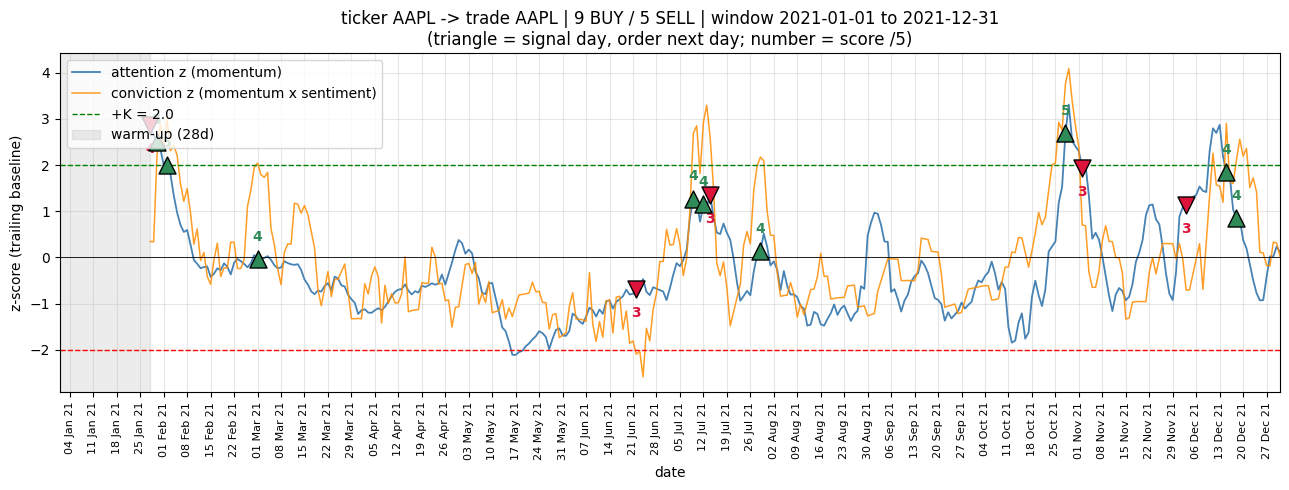

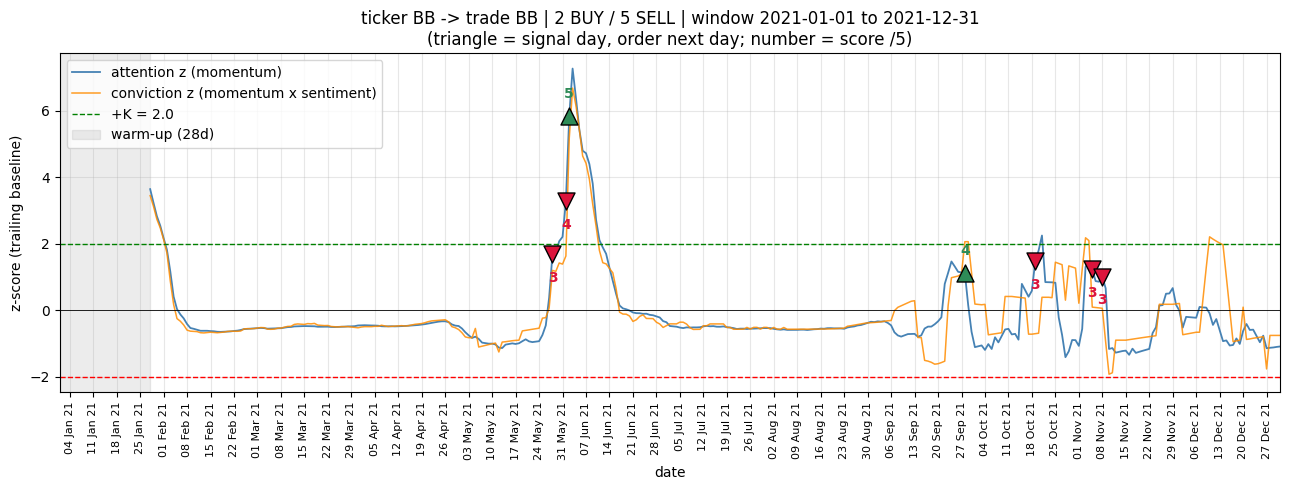

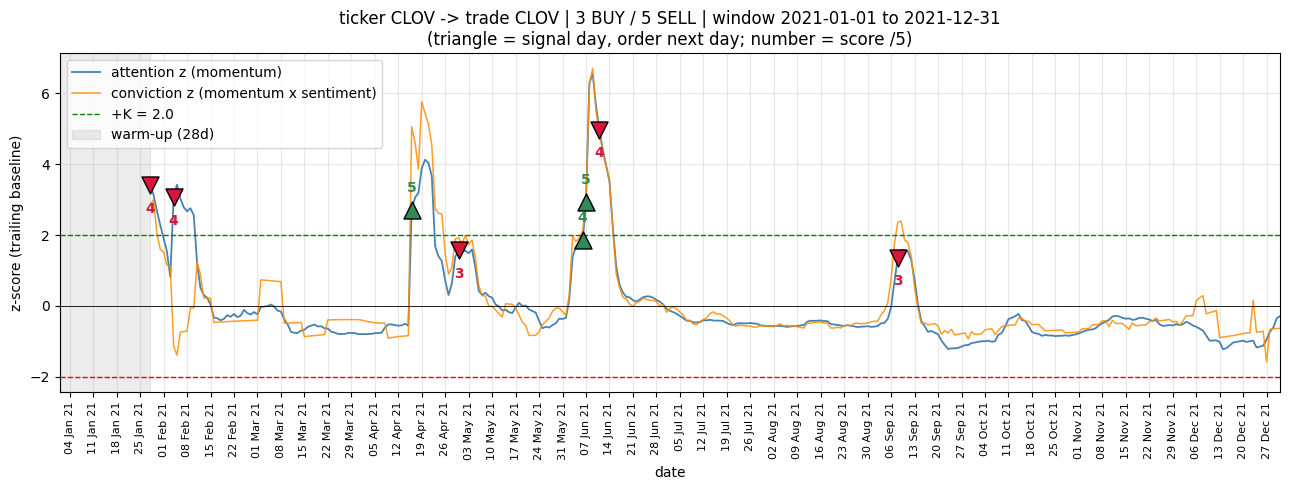

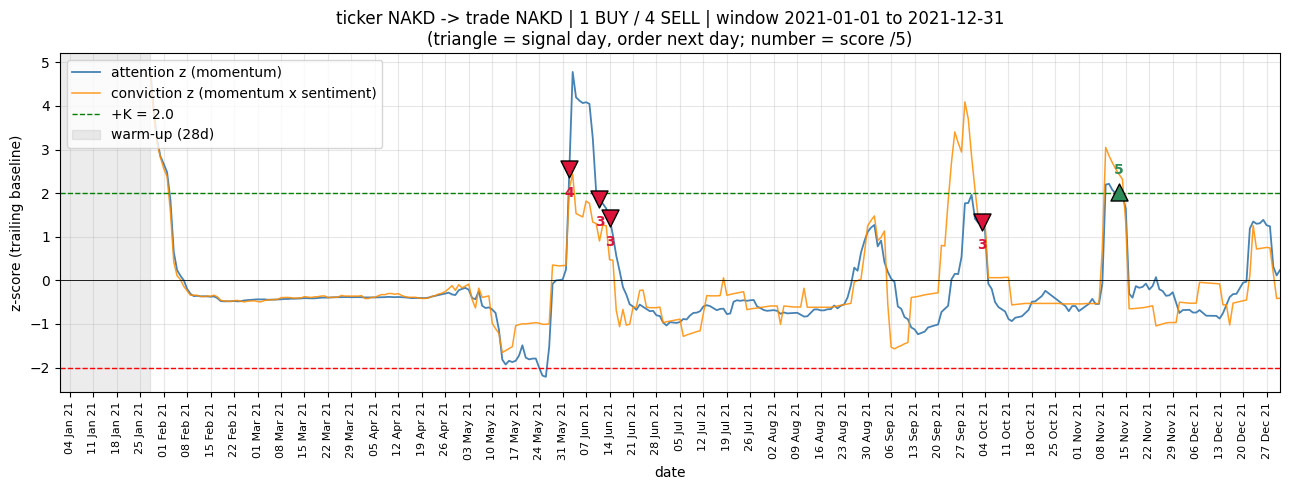

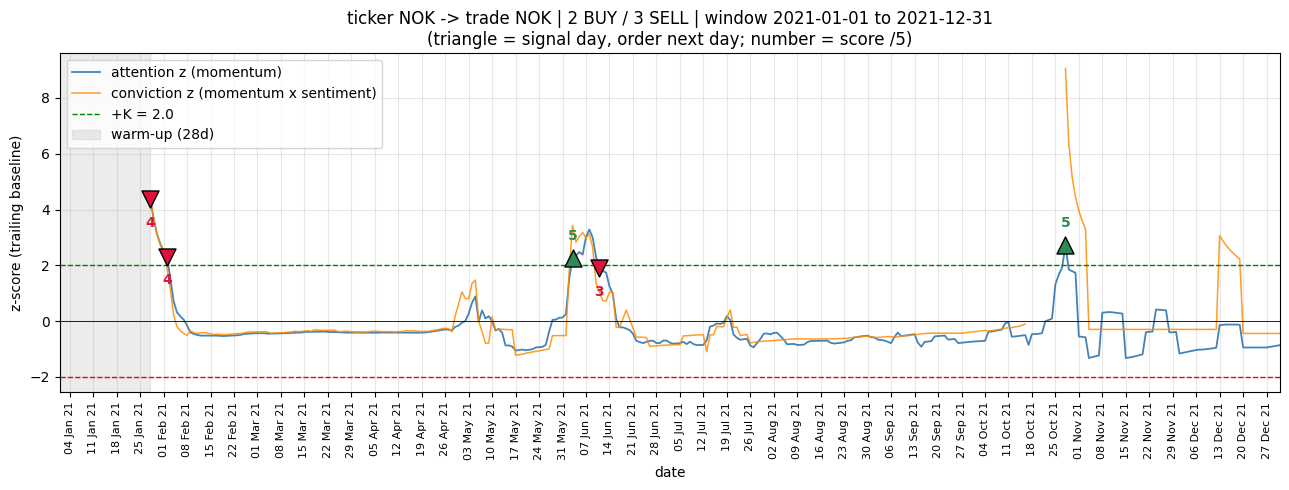

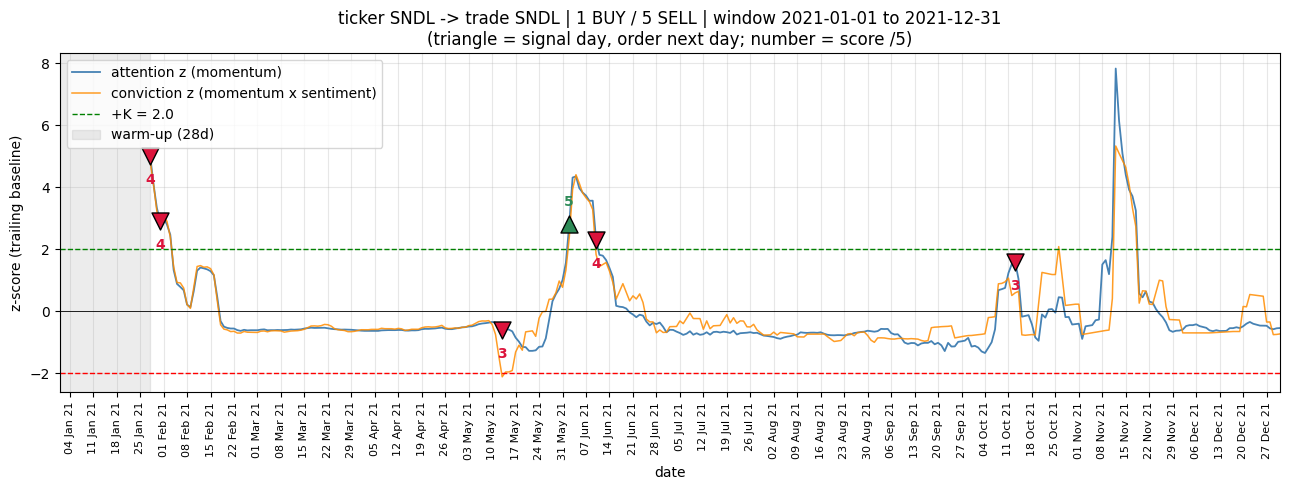

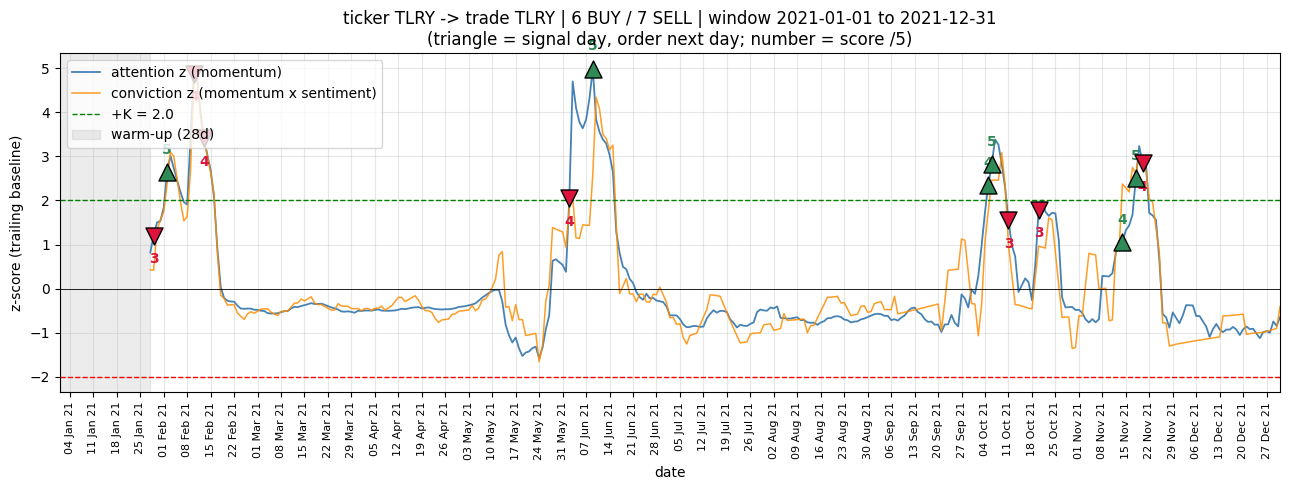

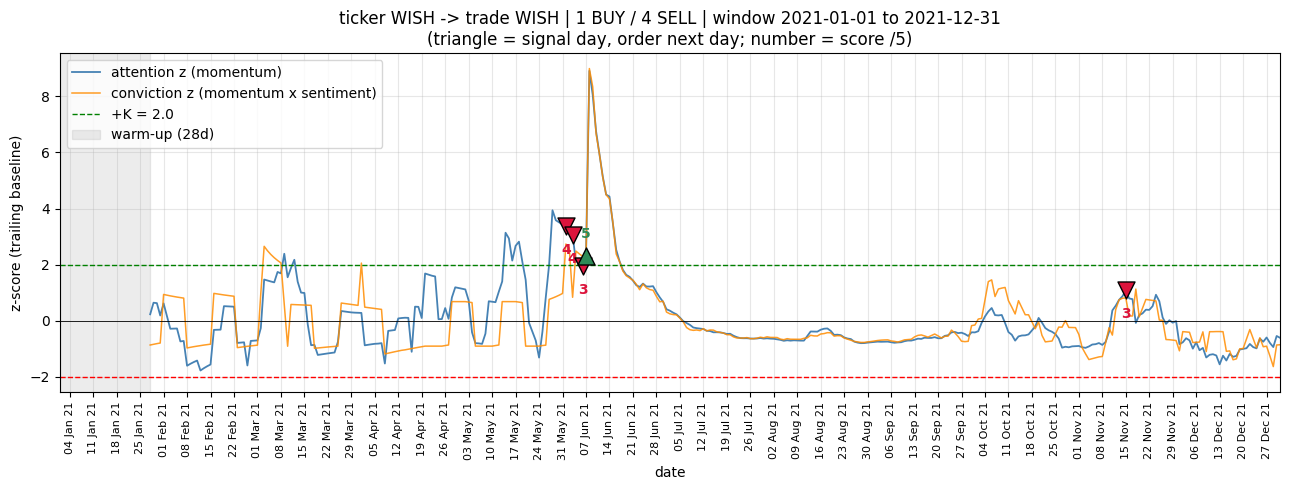

In [16]:
# Ticker charts - most-traded names first, capped at MAX_TICKER_CHARTS.
if len(ticker_trades):
    order = (ticker_trades.groupby('ticker')['score'].max()
             .sort_values(ascending=False).index.tolist())
    for tick in order[:MAX_TICKER_CHARTS]:
        plot_decisions(tick, t_att_z, t_conv_z,
                       ticker_trades[ticker_trades['ticker'] == tick],
                       tick, 'ticker')
else:
    print('no ticker decisions to chart')

## What this is and is not

- PAPER decisions with explicit reasons - whether they MADE money needs
  the price backtest (notebook 10, spec in weekly_task_lists/WEEK2.md);
  a BUY on SMH must beat simply holding SMH, and single-name results
  need delisted price histories or they are survivorship-flattered.
- The score gates trade SELECTION (>= MIN_SCORE), but not SIZE - sizing
  by score only gets added if notebook 10 shows score 5 entries actually
  beat score 4 ones (v1 discipline).
- SELL means 'open a bearish position / exit' - shorting mechanics
  (borrow, costs) are a notebook-10 concern.
- When live ingestion lands: parquets refresh daily, this notebook runs
  as the daily decision engine, and each day's signal files are
  SNAPSHOTTED, never revised (README live-data checklist).